### 1. Import & Verifikasi Versi
TorchText adalah library resmi PyTorch untuk preprocessing teks dan NLP. Library ini menyediakan tokenizer, vocabulary builder, dataset bawaan, dan integrasi langsung dengan `torch.utils.data.DataLoader`. Pastikan versinya kompatibel dengan PyTorch yang terinstall.

In [15]:
import torch
import torchtext
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator, Vocab
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

import numpy as np
import re
from collections import Counter
from typing import List, Tuple, Iterable

print(f"PyTorch version   : {torch.__version__}")
print(f"TorchText version : {torchtext.__version__}")
print(f"Device            : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version   : 1.10.0+cpu
TorchText version : 0.11.0
Device            : cpu


### 2. Tokenizer (`get_tokenizer`)
`get_tokenizer` adalah titik masuk utama tokenisasi di TorchText. Ia mendukung berbagai backend: `'basic_english'` (split sederhana), `'spacy'` (lebih akurat, butuh install spaCy), dan `'moses'` (standard machine translation). Dalam pipeline LLM, tokenizer ini biasanya dipakai sebelum membangun vocabulary kustom atau sebagai fallback ketika tidak pakai HuggingFace tokenizer.

In [16]:
# --- Tokenizer 'basic_english': split pada spasi & lowercase otomatis ---
tokenizer = get_tokenizer('basic_english')

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "BERT and GPT-2 are pre-trained language models!",
    "Loss: 2.512, Accuracy: 94.5% — epoch 3/10",
]

print("=== basic_english tokenizer ===")
for s in sentences:
    tokens = tokenizer(s)
    print(f"  Input : {s!r}")
    print(f"  Tokens: {tokens}")
    print()

# --- Tokenizer kustom berbasis regex (lebih kontrol) ---
def regex_tokenizer(text: str) -> List[str]:
    """Tokenizer sederhana berbasis regex — cocok untuk data bersih."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # hapus tanda baca
    return text.split()

custom_tok = get_tokenizer(regex_tokenizer)
print("=== Custom regex tokenizer ===")
sample = "BERT & GPT-2 are amazing models (2024)!"
print(f"  Input : {sample!r}")
print(f"  Tokens: {custom_tok(sample)}")

=== basic_english tokenizer ===
  Input : 'The quick brown fox jumps over the lazy dog.'
  Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']

  Input : 'BERT and GPT-2 are pre-trained language models!'
  Tokens: ['bert', 'and', 'gpt-2', 'are', 'pre-trained', 'language', 'models', '!']

  Input : 'Loss: 2.512, Accuracy: 94.5% — epoch 3/10'
  Tokens: ['loss', '2', '.', '512', ',', 'accuracy', '94', '.', '5%', '—', 'epoch', '3/10']

=== Custom regex tokenizer ===
  Input : 'BERT & GPT-2 are amazing models (2024)!'
  Tokens: ['bert', 'gpt', '2', 'are', 'amazing', 'models', '2024']


### 3. Membangun Vocabulary (`build_vocab_from_iterator`)
Vocabulary adalah pemetaan token → integer index. `build_vocab_from_iterator` membangun vocab dari generator token, mendukung minimum frekuensi (`min_freq`) untuk membuang token langka, dan special tokens (`<unk>`, `<pad>`, `<bos>`, `<eos>`). Vocabulary adalah komponen fundamental sebelum membuat embedding layer.

In [17]:
# Dataset teks sederhana (simulasi corpus)
corpus = [
    "the cat sat on the mat",
    "the dog ran over the hill",
    "a cat and a dog played together",
    "deep learning models need large datasets",
    "transformers use attention mechanisms for NLP tasks",
    "bert and gpt are popular language models",
    "training a large model requires a powerful gpu",
]

tokenizer = get_tokenizer('basic_english')

# Generator token dari corpus
def yield_tokens(data: List[str]) -> Iterable:
    for text in data:
        yield tokenizer(text)

# Definisikan special tokens
SPECIAL_TOKENS = ['<unk>', '<pad>', '<bos>', '<eos>']

vocab = build_vocab_from_iterator(
    yield_tokens(corpus),
    min_freq=1,                  # abaikan token yang muncul < 1 kali
    specials=SPECIAL_TOKENS,
    special_first=True           # special tokens di indeks terkecil
)

# Set default index untuk token tidak dikenal
vocab.set_default_index(vocab['<unk>'])

print(f"Ukuran vocabulary: {len(vocab)}")
print(f"\nSpecial tokens:")
for tok in SPECIAL_TOKENS:
    print(f"  '{tok}' → index {vocab[tok]}")

print(f"\nContoh token → index:")
for word in ['the', 'cat', 'model', 'gpu', 'bert']:
    print(f"  '{word}' → {vocab[word]}")

print(f"\nToken tidak dikenal → index: vocab['xyz'] = {vocab['xyz']} (<unk>)")

# Lookup batch
sample_tokens = ['deep', 'learning', 'models']
indices = vocab(sample_tokens)   # vocab bisa dipanggil seperti fungsi
print(f"\nvocab({sample_tokens}) = {indices}")

# Lookup balik: index → token
itos = vocab.get_itos()          # list of tokens (index to string)
print(f"\nindex 0-9: {itos[:10]}")

Ukuran vocabulary: 40

Special tokens:
  '<unk>' → index 0
  '<pad>' → index 1
  '<bos>' → index 2
  '<eos>' → index 3

Contoh token → index:
  'the' → 5
  'cat' → 7
  'model' → 24
  'gpu' → 18
  'bert' → 13

Token tidak dikenal → index: vocab['xyz'] = 0 (<unk>)

vocab(['deep', 'learning', 'models']) = [15, 21, 10]

index 0-9: ['<unk>', '<pad>', '<bos>', '<eos>', 'a', 'the', 'and', 'cat', 'dog', 'large']


### 4. Vocab Lanjutan: `min_freq`, Frekuensi, dan Inspeksi
Memahami distribusi frekuensi token penting untuk menentukan `min_freq` yang tepat — terlalu kecil membuat vocab membengkak, terlalu besar membuang informasi penting. Inspeksi vocab juga membantu debug saat model menghasilkan banyak `<unk>`.

In [18]:
# Simulasi corpus yang lebih besar dengan distribusi frekuensi tidak merata
large_corpus = corpus * 5  # duplikasi agar ada variasi frekuensi
large_corpus += [
    "rare_token_xyz appears only once",
    "another_rare_abc is also unique",
]

# Hitung frekuensi manual terlebih dahulu untuk analisis
all_tokens = [tok for text in large_corpus for tok in tokenizer(text)]
freq = Counter(all_tokens)

print(f"Total token (dengan duplikat): {len(all_tokens)}")
print(f"Token unik: {len(freq)}")
print(f"\n20 token terpopuler:")
for tok, cnt in freq.most_common(20):
    print(f"  '{tok}': {cnt}x")

print(f"\nToken dengan frekuensi = 1 (langka):")
rare = [tok for tok, cnt in freq.items() if cnt == 1]
print(f"  {rare}")

# Bandingkan ukuran vocab dengan min_freq berbeda
print("\n=== Perbandingan ukuran vocab berdasar min_freq ===")
for mf in [1, 2, 3, 5]:
    v = build_vocab_from_iterator(
        yield_tokens(large_corpus),
        min_freq=mf,
        specials=SPECIAL_TOKENS
    )
    print(f"  min_freq={mf} → vocab size: {len(v)}")

Total token (dengan duplikat): 243
Token unik: 44

20 token terpopuler:
  'the': 20x
  'a': 20x
  'cat': 10x
  'dog': 10x
  'and': 10x
  'models': 10x
  'large': 10x
  'sat': 5x
  'on': 5x
  'mat': 5x
  'ran': 5x
  'over': 5x
  'hill': 5x
  'played': 5x
  'together': 5x
  'deep': 5x
  'learning': 5x
  'need': 5x
  'datasets': 5x
  'transformers': 5x

Token dengan frekuensi = 1 (langka):
  ['rare_token_xyz', 'appears', 'only', 'once', 'another_rare_abc', 'is', 'also', 'unique']

=== Perbandingan ukuran vocab berdasar min_freq ===
  min_freq=1 → vocab size: 48
  min_freq=2 → vocab size: 40
  min_freq=3 → vocab size: 40
  min_freq=5 → vocab size: 40


### 5. Text Pipeline: Tokenisasi → Numericalisasi
Pipeline teks adalah rangkaian transformasi: `raw text → tokens → indices`. Ini adalah langkah utama sebelum data masuk ke model. Pipeline ini biasanya dikombinasikan menjadi satu fungsi yang dapat diaplikasikan ke seluruh dataset, termasuk penambahan special tokens `<bos>` dan `<eos>` yang umum digunakan di model Seq2Seq dan language model.

In [19]:
# Gunakan vocab yang dibangun di cell sebelumnya

# --- Pipeline dasar: text → list of indices ---
text_pipeline = lambda text: vocab(tokenizer(text))

# --- Pipeline dengan special tokens BOS/EOS ---
BOS_IDX = vocab['<bos>']
EOS_IDX = vocab['<eos>']
PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

def text_pipeline_with_specials(text: str) -> List[int]:
    """Tokenisasi + numericalisasi + tambah BOS dan EOS."""
    tokens = tokenizer(text)
    indices = vocab(tokens)
    return [BOS_IDX] + indices + [EOS_IDX]

# --- Label pipeline (untuk klasifikasi) ---
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
label_pipeline = lambda label: label_map.get(label.lower(), -1)

# Demo
test_sentences = [
    "deep learning models need large datasets",
    "bert and gpt are popular language models",
    "this token is unknown xyz abc",  # ada token <unk>
]

print("=== Pipeline Dasar ===")
for s in test_sentences:
    tokens  = tokenizer(s)
    indices = text_pipeline(s)
    print(f"  Teks    : {s!r}")
    print(f"  Tokens  : {tokens}")
    print(f"  Indices : {indices}")
    print()

print("=== Pipeline dengan BOS/EOS ===")
s = "deep learning models need large datasets"
indices_bos_eos = text_pipeline_with_specials(s)
itos = vocab.get_itos()
print(f"  Teks    : {s!r}")
print(f"  Indices : {indices_bos_eos}")
print(f"  Decoded : {[itos[i] for i in indices_bos_eos]}")

print("\n=== Label Pipeline ===")
for label in ['negative', 'Positive', 'NEUTRAL', 'unknown']:
    print(f"  '{label}' → {label_pipeline(label)}")

=== Pipeline Dasar ===
  Teks    : 'deep learning models need large datasets'
  Tokens  : ['deep', 'learning', 'models', 'need', 'large', 'datasets']
  Indices : [15, 21, 10, 25, 9, 14]

  Teks    : 'bert and gpt are popular language models'
  Tokens  : ['bert', 'and', 'gpt', 'are', 'popular', 'language', 'models']
  Indices : [13, 6, 17, 11, 30, 20, 10]

  Teks    : 'this token is unknown xyz abc'
  Tokens  : ['this', 'token', 'is', 'unknown', 'xyz', 'abc']
  Indices : [0, 0, 0, 0, 0, 0]

=== Pipeline dengan BOS/EOS ===
  Teks    : 'deep learning models need large datasets'
  Indices : [2, 15, 21, 10, 25, 9, 14, 3]
  Decoded : ['<bos>', 'deep', 'learning', 'models', 'need', 'large', 'datasets', '<eos>']

=== Label Pipeline ===
  'negative' → 0
  'Positive' → 2
  'NEUTRAL' → 1
  'unknown' → -1


### 6. Padding dan Batching (`pad_sequence`, `collate_fn`)
Sekuens teks dalam satu batch memiliki panjang yang berbeda-beda. Sebelum dimasukkan ke model, semuanya harus memiliki panjang yang sama. `torch.nn.utils.rnn.pad_sequence` melakukan padding otomatis, dan `collate_fn` adalah fungsi kunci yang dikaitkan ke `DataLoader` untuk mengontrol cara batch dibentuk dari sampel individual.

In [20]:
from torch.nn.utils.rnn import pad_sequence

# Simulasi sekuens dengan panjang berbeda-beda
raw_sequences = [
    "deep learning models need large datasets",
    "bert",
    "transformers use attention mechanisms for NLP tasks",
    "cat and dog",
]

# Konversi ke tensor
sequences_as_tensors = [
    torch.tensor(text_pipeline(s), dtype=torch.long)
    for s in raw_sequences
]

print("Panjang tiap sekuens sebelum padding:")
for i, (s, t) in enumerate(zip(raw_sequences, sequences_as_tensors)):
    print(f"  [{i}] len={len(t):3d} | {t.tolist()} | {s!r}")

# pad_sequence: tumpuk jadi (max_len, batch) lalu transpose
# batch_first=False → shape (seq_len, batch_size)
padded = pad_sequence(sequences_as_tensors, batch_first=True, padding_value=PAD_IDX)
print(f"\nShape setelah padding (batch_first=True): {padded.shape}")
print("Tensor padded:")
print(padded)

# Attention mask: 1 untuk token nyata, 0 untuk padding
attention_mask = (padded != PAD_IDX).long()
print(f"\nAttention mask shape: {attention_mask.shape}")
print(attention_mask)

# --- collate_fn untuk DataLoader ---
def collate_fn(batch: List[Tuple[int, str]]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    batch: list of (label_int, text_string)
    Returns: (padded_input_ids, attention_mask, labels)
    """
    labels, texts = zip(*batch)
    token_ids = [torch.tensor(text_pipeline_with_specials(t), dtype=torch.long) for t in texts]
    padded_ids = pad_sequence(token_ids, batch_first=True, padding_value=PAD_IDX)
    mask       = (padded_ids != PAD_IDX).long()
    labels_t   = torch.tensor(labels, dtype=torch.long)
    return padded_ids, mask, labels_t

# Demo collate_fn
sample_batch = [
    (0, "bert and gpt are popular language models"),
    (1, "the cat sat on the mat"),
    (2, "deep learning"),
]
ids, mask, lbls = collate_fn(sample_batch)
print(f"\n=== Output collate_fn ===")
print(f"  input_ids shape     : {ids.shape}")
print(f"  attention_mask shape: {mask.shape}")
print(f"  labels              : {lbls}")

Panjang tiap sekuens sebelum padding:
  [0] len=  6 | [15, 21, 10, 25, 9, 14] | 'deep learning models need large datasets'
  [1] len=  1 | [13] | 'bert'
  [2] len=  7 | [38, 39, 12, 23, 16, 26, 35] | 'transformers use attention mechanisms for NLP tasks'
  [3] len=  3 | [7, 6, 8] | 'cat and dog'

Shape setelah padding (batch_first=True): torch.Size([4, 7])
Tensor padded:
tensor([[15, 21, 10, 25,  9, 14,  1],
        [13,  1,  1,  1,  1,  1,  1],
        [38, 39, 12, 23, 16, 26, 35],
        [ 7,  6,  8,  1,  1,  1,  1]])

Attention mask shape: torch.Size([4, 7])
tensor([[1, 1, 1, 1, 1, 1, 0],
        [1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 0, 0, 0]])

=== Output collate_fn ===
  input_ids shape     : torch.Size([3, 9])
  attention_mask shape: torch.Size([3, 9])
  labels              : tensor([0, 1, 2])


### 7. Dataset Kustom + DataLoader
Membuat `torch.utils.data.Dataset` kustom untuk teks adalah pola standar di setiap proyek NLP dengan PyTorch. Dataset kustom dikombinasikan dengan `DataLoader` (menggunakan `collate_fn` dari section sebelumnya) untuk mendapatkan pipeline data yang efisien dengan batching, shuffling, dan multiprocessing.

In [21]:
class TextClassificationDataset(Dataset):
    """
    Dataset teks untuk klasifikasi sentimen.
    Input: list of (label_string, text_string)
    """
    def __init__(self, data: List[Tuple[str, str]], label_map: dict):
        self.data = data
        self.label_map = label_map

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Tuple[int, str]:
        label_str, text = self.data[idx]
        label_int = self.label_map.get(label_str.lower(), 0)
        return label_int, text


# Simulasi dataset sentimen
raw_data = [
    ('positive', 'deep learning models achieve state of the art results'),
    ('negative', 'the training loss is not converging at all'),
    ('positive', 'bert and gpt are popular language models'),
    ('neutral',  'the model uses attention mechanisms'),
    ('positive', 'transformers revolutionized the field of NLP'),
    ('negative', 'the dataset is too small for training a large model'),
    ('neutral',  'a cat and a dog played together in the yard'),
    ('positive', 'training a large model requires a powerful gpu'),
    ('negative', 'the model overfits after only a few epochs'),
    ('neutral',  'deep learning needs large datasets to work well'),
]

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

# Split train/valid
train_data = raw_data[:8]
val_data   = raw_data[8:]

train_dataset = TextClassificationDataset(train_data, label_map)
val_dataset   = TextClassificationDataset(val_data,   label_map)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")
print(f"Contoh item [0]: {train_dataset[0]}")

# DataLoader dengan collate_fn
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

# Ambil 1 batch dan inspect
input_ids, attn_mask, labels = next(iter(train_loader))
print(f"\n=== 1 Batch dari DataLoader ===")
print(f"  input_ids shape     : {input_ids.shape}")
print(f"  attention_mask shape: {attn_mask.shape}")
print(f"  labels              : {labels}")
print(f"\n  input_ids (tensor):\n{input_ids}")
print(f"\n  attention_mask:\n{attn_mask}")

Train size: 8 | Val size: 2
Contoh item [0]: (2, 'deep learning models achieve state of the art results')

=== 1 Batch dari DataLoader ===
  input_ids shape     : torch.Size([4, 12])
  attention_mask shape: torch.Size([4, 12])
  labels              : tensor([2, 0, 2, 1])

  input_ids (tensor):
tensor([[ 2, 37,  4,  9, 24, 33,  4, 31, 18,  3,  1,  1],
        [ 2,  5, 37,  0,  0,  0,  0,  0,  0,  3,  1,  1],
        [ 2, 13,  6, 17, 11, 30, 20, 10,  3,  1,  1,  1],
        [ 2,  4,  7,  6,  4,  8, 29, 36,  0,  5,  0,  3]])

  attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


### 8. Embedding Layer dengan Vocabulary (`nn.Embedding`)
Setelah vocabulary dibangun dan teks dinumericalisasi, langkah berikutnya adalah melewatkan indeks ke `nn.Embedding` untuk mendapatkan representasi vektor dense. Ini adalah blok pertama dari hampir semua model NLP — dari LSTM sederhana hingga Transformer. Ukuran embedding (`embedding_dim`) adalah hyperparameter penting.

In [22]:
VOCAB_SIZE    = len(vocab)
EMBEDDING_DIM = 64

# nn.Embedding: tabel lookup berukuran (vocab_size, embedding_dim)
embedding_layer = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    padding_idx=PAD_IDX        # gradien token <pad> tidak diupdate
)

print(f"Embedding layer: {embedding_layer}")
print(f"Weight shape: {embedding_layer.weight.shape}")
print(f"  → ({VOCAB_SIZE} token) x ({EMBEDDING_DIM} dimensi)")

# Forward pass: indeks → vektor embedding
sample_text = "deep learning models need large datasets"
sample_ids  = torch.tensor(text_pipeline(sample_text), dtype=torch.long)

with torch.no_grad():
    embeddings = embedding_layer(sample_ids)

print(f"\nTeks    : {sample_text!r}")
print(f"Indices : {sample_ids.tolist()}")
print(f"Embedding output shape: {embeddings.shape}")
print(f"  → ({len(sample_ids)} token) x ({EMBEDDING_DIM} dim)")
print(f"\nEmbedding token pertama ('{tokenizer(sample_text)[0]}'):")
print(f"  {embeddings[0][:8].tolist()}... (8 dari {EMBEDDING_DIM} dim)")

# Gunakan dengan batch dari DataLoader
with torch.no_grad():
    batch_embeddings = embedding_layer(input_ids)  # input_ids dari DataLoader sebelumnya

print(f"\nBatch embedding shape: {batch_embeddings.shape}")
print(f"  → (batch={input_ids.shape[0]}) x (seq_len={input_ids.shape[1]}) x (dim={EMBEDDING_DIM})")

Embedding layer: Embedding(40, 64, padding_idx=1)
Weight shape: torch.Size([40, 64])
  → (40 token) x (64 dimensi)

Teks    : 'deep learning models need large datasets'
Indices : [15, 21, 10, 25, 9, 14]
Embedding output shape: torch.Size([6, 64])
  → (6 token) x (64 dim)

Embedding token pertama ('deep'):
  [-1.3249884843826294, 0.035406444221735, 0.4426546096801758, 0.6674321293830872, -0.24492168426513672, -0.4166358411312103, 0.5989105105400085, -0.9380084276199341]... (8 dari 64 dim)

Batch embedding shape: torch.Size([4, 12, 64])
  → (batch=4) x (seq_len=12) x (dim=64)


### 9. Pre-trained Vectors: GloVe & FastText (`torchtext.vocab.Vectors`)
Daripada training embedding dari nol (random initialization), kita bisa memuat vektor pre-trained seperti **GloVe** atau **FastText** yang sudah dilatih pada korpus besar (Wikipedia, Common Crawl). Ini memberikan representasi awal yang jauh lebih baik, terutama untuk dataset kecil. TorchText menyediakan wrapper langsung untuk vektor-vektor populer ini.

In [23]:
from torchtext.vocab import GloVe, FastText

# --- CATATAN: Download GloVe (membutuhkan koneksi internet pertama kali) ---
# GloVe tersedia dalam beberapa dimensi: 50, 100, 200, 300
# FastText tersedia untuk banyak bahasa termasuk Bahasa Indonesia

# Simulasi: karena download cukup besar (~800MB untuk GloVe-6B),
# kita demonstrasikan cara penggunaannya tanpa benar-benar mendownload

print("=== Cara Memuat GloVe Pre-trained Vectors ===")
print("""
# Load GloVe (100-dimensional, trained on 6B tokens from Wikipedia)
glove_vectors = GloVe(name='6B', dim=100)
# name options: '6B', '42B', '840B'
# dim options:  50, 100, 200, 300

# Load FastText (300-dimensional, multilingual support)
fasttext_vectors = FastText(language='en')
# language: 'en', 'id' (Indonesian), 'de', 'fr', dll.
""")

print("=== Cara Membuat Embedding Layer dari Pre-trained Vectors ===")
pretrained_code = '''
# 1. Load vektornya
glove = GloVe(name='6B', dim=100)

# 2. Bangun vocab yang sesuai dengan dataset kita
vocab = build_vocab_from_iterator(yield_tokens(corpus), specials=['<unk>', '<pad>'])
vocab.set_default_index(vocab['<unk>'])

# 3. Buat embedding matrix dari pre-trained vectors
embedding_matrix = glove.get_vecs_by_tokens(vocab.get_itos(), lower_case_backup=True)
# Shape: (vocab_size, 100)

# 4. Init nn.Embedding dengan pre-trained weights
embedding_layer = nn.Embedding.from_pretrained(
    embeddings=embedding_matrix,
    freeze=False,        # True = frozen (tidak di-update saat training)
    padding_idx=vocab['<pad>']
)
'''
print(pretrained_code)

# --- Demo dengan embedding acak sebagai pengganti pre-trained ---
print("\n=== Demo: Inisialisasi Embedding dari Matrix (simulasi pre-trained) ===")
FAKE_DIM = 50
np.random.seed(42)
fake_pretrained = np.random.randn(len(vocab), FAKE_DIM).astype(np.float32)

# Pastikan <pad> tokennya nol
fake_pretrained[PAD_IDX] = 0.0

embedding_from_pretrained = nn.Embedding.from_pretrained(
    embeddings=torch.tensor(fake_pretrained),
    freeze=False,
    padding_idx=PAD_IDX
)

print(f"  Embedding dari pre-trained matrix: {embedding_from_pretrained}")
print(f"  Weight shape: {embedding_from_pretrained.weight.shape}")
print(f"  <pad> token row (harus semua 0): {embedding_from_pretrained.weight[PAD_IDX].tolist()[:5]}...")

=== Cara Memuat GloVe Pre-trained Vectors ===

# Load GloVe (100-dimensional, trained on 6B tokens from Wikipedia)
glove_vectors = GloVe(name='6B', dim=100)
# name options: '6B', '42B', '840B'
# dim options:  50, 100, 200, 300

# Load FastText (300-dimensional, multilingual support)
fasttext_vectors = FastText(language='en')
# language: 'en', 'id' (Indonesian), 'de', 'fr', dll.

=== Cara Membuat Embedding Layer dari Pre-trained Vectors ===

# 1. Load vektornya
glove = GloVe(name='6B', dim=100)

# 2. Bangun vocab yang sesuai dengan dataset kita
vocab = build_vocab_from_iterator(yield_tokens(corpus), specials=['<unk>', '<pad>'])
vocab.set_default_index(vocab['<unk>'])

# 3. Buat embedding matrix dari pre-trained vectors
embedding_matrix = glove.get_vecs_by_tokens(vocab.get_itos(), lower_case_backup=True)
# Shape: (vocab_size, 100)

# 4. Init nn.Embedding dengan pre-trained weights
embedding_layer = nn.Embedding.from_pretrained(
    embeddings=embedding_matrix,
    freeze=False,        # 

### 10. Dataset Bawaan TorchText (`torchtext.datasets`)
TorchText menyediakan dataset NLP populer yang dapat diunduh secara otomatis: **AG_NEWS** (klasifikasi berita), **SST2** (sentimen), **IMDB** (review film), **Multi30k** (terjemahan), dll. Ini sangat berguna untuk benchmarking dan eksperimen cepat tanpa perlu menyiapkan data sendiri.

In [24]:
# --- CATATAN: Dataset bawaan membutuhkan koneksi internet saat pertama kali dijalankan ---
# Data akan di-cache di ~/.cache/torchtext/ setelah download pertama

print("=== Dataset Bawaan yang Tersedia di torchtext.datasets ===")
print("""
Daftar dataset populer:
  - AG_NEWS     : 4-class berita (World, Sports, Business, Sci/Tech) — 120K train
  - SST2        : Sentimen biner (positif/negatif) — Stanford Sentiment Treebank
  - IMDB        : Review film biner — 25K train + 25K test
  - YelpReviewFull : 5-class Yelp review — 650K samples
  - AmazonReviewFull: 5-class Amazon review — 3.6M samples
  - Multi30k    : Terjemahan EN↔DE (image captioning)
  - WMT14       : Machine Translation EN↔DE skala besar
""")

print("=== Cara Penggunaan AG_NEWS ===")
agnews_code = '''
from torchtext.datasets import AG_NEWS

# Load dataset — download otomatis jika belum ada
train_iter, test_iter = AG_NEWS(split=('train', 'test'))

# Setiap item adalah tuple (label, text)
# label: 1=World, 2=Sports, 3=Business, 4=Sci/Tech
for label, text in train_iter:
    print(f"Label: {label}")
    print(f"Text: {text[:100]}")
    break  # hanya lihat 1 contoh
'''
print(agnews_code)

print("=== Pipeline Lengkap dengan AG_NEWS ===")
full_pipeline_code = '''
from torchtext.datasets import AG_NEWS
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

tokenizer = get_tokenizer('basic_english')
train_iter = AG_NEWS(split='train')

# Build vocab dari training data
def yield_tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text)

vocab = build_vocab_from_iterator(
    yield_tokens(train_iter),
    min_freq=2,
    specials=['<unk>', '<pad>']
)
vocab.set_default_index(vocab['<unk>'])

# Pipeline
text_pipeline  = lambda x: vocab(tokenizer(x))
label_pipeline = lambda x: int(x) - 1  # 1-indexed → 0-indexed

# collate_fn + DataLoader
from torch.nn.utils.rnn import pad_sequence

def collate_batch(batch):
    labels, texts = zip(*batch)
    token_ids = [torch.tensor(text_pipeline(t)) for t in texts]
    padded    = pad_sequence(token_ids, batch_first=True, padding_value=vocab['<pad>'])
    lbls      = torch.tensor([label_pipeline(l) for l in labels])
    return padded, lbls

train_iter = AG_NEWS(split='train')  # reset iterator
loader = DataLoader(list(train_iter), batch_size=32, shuffle=True, collate_fn=collate_batch)
'''
print(full_pipeline_code)

=== Dataset Bawaan yang Tersedia di torchtext.datasets ===

Daftar dataset populer:
  - AG_NEWS     : 4-class berita (World, Sports, Business, Sci/Tech) — 120K train
  - SST2        : Sentimen biner (positif/negatif) — Stanford Sentiment Treebank
  - IMDB        : Review film biner — 25K train + 25K test
  - YelpReviewFull : 5-class Yelp review — 650K samples
  - AmazonReviewFull: 5-class Amazon review — 3.6M samples
  - Multi30k    : Terjemahan EN↔DE (image captioning)
  - WMT14       : Machine Translation EN↔DE skala besar

=== Cara Penggunaan AG_NEWS ===

from torchtext.datasets import AG_NEWS

# Load dataset — download otomatis jika belum ada
train_iter, test_iter = AG_NEWS(split=('train', 'test'))

# Setiap item adalah tuple (label, text)
# label: 1=World, 2=Sports, 3=Business, 4=Sci/Tech
for label, text in train_iter:
    print(f"Label: {label}")
    print(f"Text: {text[:100]}")
    break  # hanya lihat 1 contoh

=== Pipeline Lengkap dengan AG_NEWS ===

from torchtext.datasets im

### 11. Model Klasifikasi Teks Sederhana (End-to-End)
Menggabungkan semua komponen sebelumnya: vocab → embedding → pooling → classifier. Ini adalah arsitektur dasar sebelum naik ke Transformer. Memahami alur ini penting karena merupakan fondasi dari semua model NLP yang lebih kompleks.

In [25]:
import torch.nn.functional as F

class TextClassifier(nn.Module):
    """
    Model klasifikasi teks sederhana:
    Embedding → Mean Pooling → Linear → Output
    """
    def __init__(self, vocab_size: int, embed_dim: int,
                 num_classes: int, pad_idx: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor = None) -> torch.Tensor:
        # input_ids: (batch, seq_len)
        x = self.embedding(input_ids)   # (batch, seq_len, embed_dim)

        # Mean pooling: rata-rata hanya token yang bukan padding
        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).float()  # (batch, seq_len, 1)
            x = (x * mask_expanded).sum(dim=1)                   # (batch, embed_dim)
            x = x / mask_expanded.sum(dim=1).clamp(min=1e-9)     # normalisasi
        else:
            x = x.mean(dim=1)           # (batch, embed_dim)

        x = self.dropout(x)
        return self.fc(x)               # (batch, num_classes)


# Inisialisasi model
NUM_CLASSES   = 3  # negative, neutral, positive
EMBED_DIM     = 64
VOCAB_SIZE    = len(vocab)

model = TextClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES, PAD_IDX)
print(model)
print(f"\nTotal parameter: {sum(p.numel() for p in model.parameters()):,}")

# Forward pass dengan 1 batch dari DataLoader
model.eval()
with torch.no_grad():
    logits = model(input_ids, attn_mask)
    probs  = F.softmax(logits, dim=-1)
    preds  = logits.argmax(dim=-1)

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
print(f"\n=== Forward Pass Output ===")
print(f"  Logits shape : {logits.shape}")
print(f"  Logits       : {logits}")
print(f"  Probabilities: {probs}")
print(f"  Prediksi     : {[label_names[p.item()] for p in preds]}")
print(f"  Label asli   : {[label_names[l.item()] for l in labels]}")

TextClassifier(
  (embedding): Embedding(40, 64, padding_idx=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

Total parameter: 2,755

=== Forward Pass Output ===
  Logits shape : torch.Size([4, 3])
  Logits       : tensor([[ 0.1307,  0.1739,  0.2493],
        [-0.5765,  0.1994,  0.8591],
        [ 0.0789, -0.0860, -0.0122],
        [-0.3620,  0.0551,  0.2257]])
  Probabilities: tensor([[0.3155, 0.3294, 0.3552],
        [0.1356, 0.2946, 0.5698],
        [0.3622, 0.3071, 0.3307],
        [0.2316, 0.3515, 0.4169]])
  Prediksi     : ['positive', 'positive', 'negative', 'positive']
  Label asli   : ['positive', 'negative', 'positive', 'neutral']


### 12. Training Loop Lengkap
Menggabungkan DataLoader, model, loss function, dan optimizer menjadi training loop yang lengkap. Ini adalah pola baku training model NLP dengan PyTorch yang perlu dikuasai sebelum beralih ke Hugging Face Trainer atau Lightning yang lebih abstrak.

In [26]:
from torch.optim import Adam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = TextClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES, PAD_IDX).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for input_ids, attn_mask, labels in loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        labels    = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * len(labels)
        total_correct += (logits.argmax(dim=-1) == labels).sum().item()
        total_samples += len(labels)

    return total_loss / total_samples, total_correct / total_samples


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for input_ids, attn_mask, labels in loader:
            input_ids = input_ids.to(device)
            attn_mask = attn_mask.to(device)
            labels    = labels.to(device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)

            total_loss    += loss.item() * len(labels)
            total_correct += (logits.argmax(dim=-1) == labels).sum().item()
            total_samples += len(labels)

    return total_loss / total_samples, total_correct / total_samples


# Training
NUM_EPOCHS = 10
print(f"Training pada device: {device}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
print("-" * 55)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f"{epoch:>6} {tr_loss:>12.4f} {tr_acc:>10.4f} {vl_loss:>10.4f} {vl_acc:>9.4f}")

Training pada device: cpu
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       1.0398     0.3750     1.3890    0.0000
     2       1.1042     0.3750     1.3858    0.0000
     3       1.1429     0.3750     1.3868    0.0000
     4       1.2510     0.5000     1.3836    0.0000
     5       1.0988     0.5000     1.3778    0.0000
     6       1.1933     0.5000     1.3712    0.0000
     7       1.0815     0.5000     1.3626    0.0000
     8       1.1274     0.3750     1.3544    0.0000
     9       1.1061     0.3750     1.3480    0.0000
    10       1.0759     0.5000     1.3453    0.0000


### 13. Inference: Prediksi Teks Baru
Setelah model terlatih, langkah inference mengikuti pipeline yang sama: text → tokenize → numericalize → tensor → model → decode prediction. Penting untuk memanggil `model.eval()` dan menggunakan `torch.no_grad()` agar tidak menghitung gradien yang tidak dibutuhkan saat inferensi.

In [27]:
import torch.nn.functional as F

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

def predict(text: str, model: nn.Module, vocab, tokenizer,
            device: torch.device) -> dict:
    """Prediksi sentimen dari satu teks."""
    model.eval()
    with torch.no_grad():
        # Tokenisasi & numericalisasi
        token_ids = text_pipeline_with_specials(text)
        ids_t     = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, seq_len)
        mask_t    = (ids_t != PAD_IDX).long()

        # Forward pass
        logits = model(ids_t, mask_t)          # (1, num_classes)
        probs  = F.softmax(logits, dim=-1)[0]  # (num_classes,)
        pred   = probs.argmax().item()

    return {
        'label'      : label_names[pred],
        'confidence' : probs[pred].item(),
        'all_probs'  : {label_names[i]: round(p.item(), 4) for i, p in enumerate(probs)},
        'tokens'     : [vocab.get_itos()[i] for i in token_ids],
    }


# Test pada beberapa kalimat baru
test_texts = [
    "deep learning models are amazing and powerful",
    "the training process is very slow and the loss is not decreasing",
    "bert uses attention mechanisms in the transformer architecture",
    "this model is completely useless and broken",
]

print("=== Inference Hasil Prediksi ===")
for text in test_texts:
    result = predict(text, model, vocab, tokenizer, device)
    print(f"\n  Teks       : {text!r}")
    print(f"  Prediksi   : {result['label'].upper()} (confidence: {result['confidence']:.4f})")
    print(f"  Semua prob : {result['all_probs']}")
    print(f"  Tokens     : {result['tokens']}")

=== Inference Hasil Prediksi ===

  Teks       : 'deep learning models are amazing and powerful'
  Prediksi   : POSITIVE (confidence: 0.3977)
  Semua prob : {'negative': 0.2538, 'neutral': 0.3485, 'positive': 0.3977}
  Tokens     : ['<bos>', 'deep', 'learning', 'models', 'are', '<unk>', 'and', 'powerful', '<eos>']

  Teks       : 'the training process is very slow and the loss is not decreasing'
  Prediksi   : POSITIVE (confidence: 0.4782)
  Semua prob : {'negative': 0.2628, 'neutral': 0.259, 'positive': 0.4782}
  Tokens     : ['<bos>', 'the', 'training', '<unk>', '<unk>', '<unk>', '<unk>', 'and', 'the', '<unk>', '<unk>', '<unk>', '<unk>', '<eos>']

  Teks       : 'bert uses attention mechanisms in the transformer architecture'
  Prediksi   : POSITIVE (confidence: 0.4492)
  Semua prob : {'negative': 0.2603, 'neutral': 0.2905, 'positive': 0.4492}
  Tokens     : ['<bos>', 'bert', '<unk>', 'attention', 'mechanisms', '<unk>', 'the', '<unk>', '<unk>', '<eos>']

  Teks       : 'this model is

<Axes: >

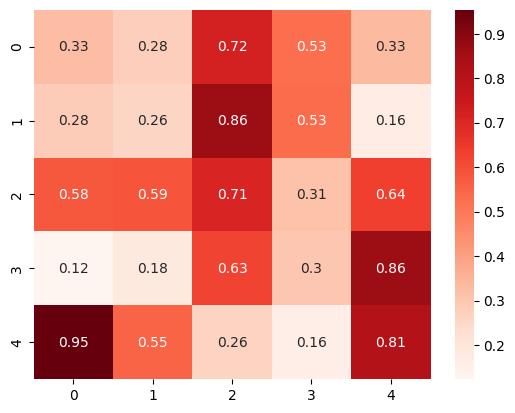

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = np.random.rand(5, 5)

# Menggunakan cmap "Reds"
sns.heatmap(data, annot=True, cmap="Reds")

In [2]:
sns.heatmap?

Signature:
sns.heatmap(
    data,
    *,
    vmin=None,
    vmax=None,
    cmap=None,
    center=None,
    robust=False,
    annot=None,
    fmt='.2g',
    annot_kws=None,
    linewidths=0,
    linecolor='white',
    cbar=True,
    cbar_kws=None,
    cbar_ax=None,
    square=False,
    xticklabels='auto',
    yticklabels='auto',
    mask=None,
    ax=None,
    **kwargs,
)
Docstring:
Plot rectangular data as a color-encoded matrix.

This is an Axes-level function and will draw the heatmap into the
currently-active Axes if none is provided to the ``ax`` argument.  Part of
this Axes space will be taken and used to plot a colormap, unless ``cbar``
is False or a separate Axes is provided to ``cbar_ax``.

Parameters
----------
data : rectangular dataset
    2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
    is provided, the index/column information will be used to label the
    columns and rows.
vmin, vmax : floats, optional
    Values to anchor the colormap, otherwise

In [3]:
sorted(list(plt.colormaps()))

['Accent',
 'Accent_r',
 'Blues',
 'Blues_r',
 'BrBG',
 'BrBG_r',
 'BuGn',
 'BuGn_r',
 'BuPu',
 'BuPu_r',
 'CMRmap',
 'CMRmap_r',
 'Dark2',
 'Dark2_r',
 'GnBu',
 'GnBu_r',
 'Grays',
 'Grays_r',
 'Greens',
 'Greens_r',
 'Greys',
 'Greys_r',
 'OrRd',
 'OrRd_r',
 'Oranges',
 'Oranges_r',
 'PRGn',
 'PRGn_r',
 'Paired',
 'Paired_r',
 'Pastel1',
 'Pastel1_r',
 'Pastel2',
 'Pastel2_r',
 'PiYG',
 'PiYG_r',
 'PuBu',
 'PuBuGn',
 'PuBuGn_r',
 'PuBu_r',
 'PuOr',
 'PuOr_r',
 'PuRd',
 'PuRd_r',
 'Purples',
 'Purples_r',
 'RdBu',
 'RdBu_r',
 'RdGy',
 'RdGy_r',
 'RdPu',
 'RdPu_r',
 'RdYlBu',
 'RdYlBu_r',
 'RdYlGn',
 'RdYlGn_r',
 'Reds',
 'Reds_r',
 'Set1',
 'Set1_r',
 'Set2',
 'Set2_r',
 'Set3',
 'Set3_r',
 'Spectral',
 'Spectral_r',
 'Wistia',
 'Wistia_r',
 'YlGn',
 'YlGnBu',
 'YlGnBu_r',
 'YlGn_r',
 'YlOrBr',
 'YlOrBr_r',
 'YlOrRd',
 'YlOrRd_r',
 'afmhot',
 'afmhot_r',
 'autumn',
 'autumn_r',
 'berlin',
 'berlin_r',
 'binary',
 'binary_r',
 'bone',
 'bone_r',
 'brg',
 'brg_r',
 'bwr',
 'bwr_r',
 'ci